# Luppi2026-style Hopf GEC fitting example

This notebook demonstrates a compact `nmp_modeling` workflow for fitting Hopf generative effective connectivity (GEC) with Luppi2026-style data, preprocessing, and optimization settings.

It uses the local `data/` folder copied from the [`competitive-cooperative-hopf`](https://github.com/Hana-Ali/competitive-cooperative-hopf/tree/main/data) repository:

- `data/matlab/single/SC.mat`
- `data/matlab/single/FMRI.mat`
- `data/matlab/debug/debug_metrics_inputs.mat`
- `data/matlab/debug/debug_metrics_outputs.mat`

The notebook first evaluates a linear Hopf approximation using `GenericHopf.get_jacobian()`, then runs nonlinear Hopf simulations through `NeuronumbaAdapter` (which requires a local [`src/`](https://github.com/neich/neuronumba/tree/main/src) folder). Both parts compare cooperative-only and cooperative–competitive GEC fitting.

In [1]:
# Cell 1: path setup and imports
# The local Neuronumba source tree is expected at ./src next to this notebook.
# The nmp_modeling package is found by walking upward from the current directory.

from pathlib import Path
import sys

HERE = Path.cwd().resolve()
NEURONUMBA_SRC = HERE / "src"
PROJECT_ROOT = next(
    (p for p in [HERE, *HERE.parents] if (p / "nmp_modeling").exists()),
    None,
)

if not NEURONUMBA_SRC.exists():
    raise RuntimeError("Expected local Neuronumba source folder at ./src next to this notebook.")
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find project root containing the nmp_modeling package.")

for path in [PROJECT_ROOT, NEURONUMBA_SRC]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import detrend

from nmp_modeling.adapters.neuronumba import NeuronumbaAdapter
from nmp_modeling.adapters.neuronumba.models.generic_hopf import GenericHopf
from nmp_modeling.hopf.frequency import estimate_peak_frequency
from nmp_modeling.hopf.gec import fit_lagcov_gec
from nmp_modeling.observables import (
    compute_fc,
    compute_normalized_shifted_covariance,
    matrix_edges,
)

In [2]:
# Cell 2: configuration, helper functions, and data loading
# Values follow the single-dataset configuration in the Luppi2026 repository.

DATA_DIR = HERE / "data" / "matlab" / "single"
DEBUG_DIR = HERE / "data" / "matlab" / "debug"

TR_SECONDS = 0.72
BAND = (0.008, 0.09)
LAG = 1  # Matches Luppi repo tau=1; one lag equals one TR.

MAX_C_COOP = 0.2
MAX_C_COMP = 0.1

A_PARAM = -0.02
SIGMA = 0.001
LEARNING_RATE_FC = 0.001
ALPHA_L1 = 0.0001
N_ITER = 2000
RELATIVE_TOLERANCE = 0.0005
RUN_SEEDS = [1]


def load_mat_variable(path, name):
    """Load one named variable from a MATLAB file."""
    return np.asarray(loadmat(path, squeeze_me=True, struct_as_record=False)[name], dtype=float)


def as_time_by_nodes(fmri, n_nodes):
    """Convert Luppi N-by-T BOLD data to the project T-by-N convention."""
    fmri = np.asarray(fmri, dtype=float)
    if fmri.shape[0] == n_nodes:
        return fmri.T
    if fmri.shape[1] == n_nodes:
        return fmri
    raise ValueError("FMRI shape is not compatible with the SC node count.")


def offdiag_corr(a, b):
    """Return Pearson correlation between upper-triangle off-diagonal entries."""
    return float(np.corrcoef(matrix_edges(a), matrix_edges(b))[0, 1])


def all_offdiag_corr(a, b):
    """Return Pearson correlation between all off-diagonal entries."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = ~np.eye(a.shape[0], dtype=bool)
    return float(np.corrcoef(a[mask], b[mask])[0, 1])


def gec_sign_counts(gec):
    """Return positive and negative GEC value counts."""
    gec = np.asarray(gec, dtype=float)
    return int(np.count_nonzero(gec > 0.0)), int(np.count_nonzero(gec < 0.0))


SC = load_mat_variable(DATA_DIR / "SC.mat", "SC")
FMRI = load_mat_variable(DATA_DIR / "FMRI.mat", "FMRI")

np.fill_diagonal(SC, 0.0)
TS = as_time_by_nodes(FMRI, n_nodes=SC.shape[0])

print("SC shape        :", SC.shape)
print("Time series     :", TS.shape)

SC shape        : (100, 100)
Time series     : (1189, 100)


In [3]:
# Cell 3: empirical targets and debug validation
# Frequency estimation follows the repository's band-pass + FFT peak + Gaussian smoothing.
# FC and lagged covariance targets use the repository's detrend preprocessing.

frequencies = estimate_peak_frequency(
    TS,
    tr_seconds=TR_SECONDS,
    band=BAND,
    normalize_by_variance=False,
)

EMP_TS = detrend(TS, axis=0, type="linear")
EMP_FC = compute_fc(EMP_TS)
EMP_LAG = compute_normalized_shifted_covariance(EMP_TS, lag=LAG)

debug_inputs = loadmat(DEBUG_DIR / "debug_metrics_inputs.mat", squeeze_me=True, struct_as_record=False)
debug_outputs = loadmat(DEBUG_DIR / "debug_metrics_outputs.mat", squeeze_me=True, struct_as_record=False)

debug_ts = as_time_by_nodes(debug_inputs["FMRI"], n_nodes=debug_inputs["SC"].shape[0])
debug_fc = compute_fc(detrend(debug_ts, axis=0, type="linear"))
debug_ref_fc = np.asarray(debug_outputs["empirical_metrics"].FC, dtype=float)
debug_mask = ~np.eye(debug_fc.shape[0], dtype=bool)
debug_max_diff = np.max(np.abs(debug_fc[debug_mask] - debug_ref_fc[debug_mask]))
debug_r = np.corrcoef(debug_fc[debug_mask], debug_ref_fc[debug_mask])[0, 1]

print("Frequency range :", f"{frequencies.min():.4f} - {frequencies.max():.4f} Hz")
print("Empirical FC    :", EMP_FC.shape)
print("Empirical lagcov:", EMP_LAG.shape)
print("Debug FC check  :", f"max off-diagonal diff={debug_max_diff:.3g}, r={debug_r:.8f}")

Frequency range : 0.0152 - 0.0374 Hz
Empirical FC    : (100, 100)
Empirical lagcov: (100, 100)
Debug FC check  : max off-diagonal diff=0.000192, r=0.99999999


In [4]:
# Cell 4: plotting helper

def summarize_result(name, result):
    """Print a compact summary of one GEC fit."""
    pos_count, neg_count = gec_sign_counts(result.gec)
    print(
        f"{name:12s} | best_iter={result.best_iter:4d} "
        f"| best_loss={result.best_loss:.6g} "
        f"| FC r={offdiag_corr(EMP_FC, result.simulated_fc):.4f} "
        f"| lag r={all_offdiag_corr(EMP_LAG, result.simulated_normalized_shifted_covariance):.4f} "
        f"| positive={pos_count:d}, negative={neg_count:d} "
        f"| stop={result.stop_reason}"
    )


def plot_luppi_style_comparison(title, cooperative, competitive):
    """Plot cooperative-only and cooperative-competitive GEC/FC results."""
    coop_fc_r = offdiag_corr(EMP_FC, cooperative.simulated_fc)
    comp_fc_r = offdiag_corr(EMP_FC, competitive.simulated_fc)

    gec_abs = np.percentile(
        np.abs(np.r_[cooperative.gec.ravel(), competitive.gec.ravel()]),
        99,
    )
    gec_abs = max(float(gec_abs), np.finfo(float).eps)

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))

    im = axes[0, 0].imshow(cooperative.gec, cmap="coolwarm", vmin=-gec_abs, vmax=gec_abs)
    axes[0, 0].set_title("Cooperative GEC")
    plt.colorbar(im, ax=axes[0, 0], fraction=0.046)
    im = axes[0, 1].imshow(competitive.gec, cmap="coolwarm", vmin=-gec_abs, vmax=gec_abs)
    axes[0, 1].set_title("Competitive GEC")
    plt.colorbar(im, ax=axes[0, 1], fraction=0.046)
    axes[0, 2].bar(["Coop", "Comp"], [coop_fc_r, comp_fc_r])
    axes[0, 2].set_ylim(0.0, 1.0)
    axes[0, 2].set_ylabel("FC correlation")
    axes[0, 2].set_title("FC fit")

    im = axes[1, 0].imshow(cooperative.simulated_fc, cmap="coolwarm", vmin=-1.0, vmax=1.0)
    axes[1, 0].set_title(f"Coop simulated FC (r={coop_fc_r:.3f})")
    plt.colorbar(im, ax=axes[1, 0], fraction=0.046)
    im = axes[1, 1].imshow(competitive.simulated_fc, cmap="coolwarm", vmin=-1.0, vmax=1.0)
    axes[1, 1].set_title(f"Comp simulated FC (r={comp_fc_r:.3f})")
    plt.colorbar(im, ax=axes[1, 1], fraction=0.046)
    im = axes[1, 2].imshow(EMP_FC, cmap="coolwarm", vmin=-1.0, vmax=1.0)
    axes[1, 2].set_title("Empirical FC")
    plt.colorbar(im, ax=axes[1, 2], fraction=0.046)

    # GEC axes
    axes[0, 0].set_xlabel("Source node")
    axes[0, 0].set_ylabel("Target node")
    axes[0, 1].set_xlabel("Source node")
    axes[0, 1].set_ylabel("Target node")

    # FC axes
    for ax in [axes[1, 0], axes[1, 1], axes[1, 2]]:
        ax.set_xlabel("Node")
        ax.set_ylabel("Node")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

Linear coop  | best_iter= 279 | best_loss=0.0685037 | FC r=0.6230 | lag r=0.6194 | positive=1266, negative=0 | stop=loss increased at checkpoint
Linear comp  | best_iter=1296 | best_loss=0.0388076 | FC r=0.8153 | lag r=0.8123 | positive=1415, negative=845 | stop=loss increased at checkpoint


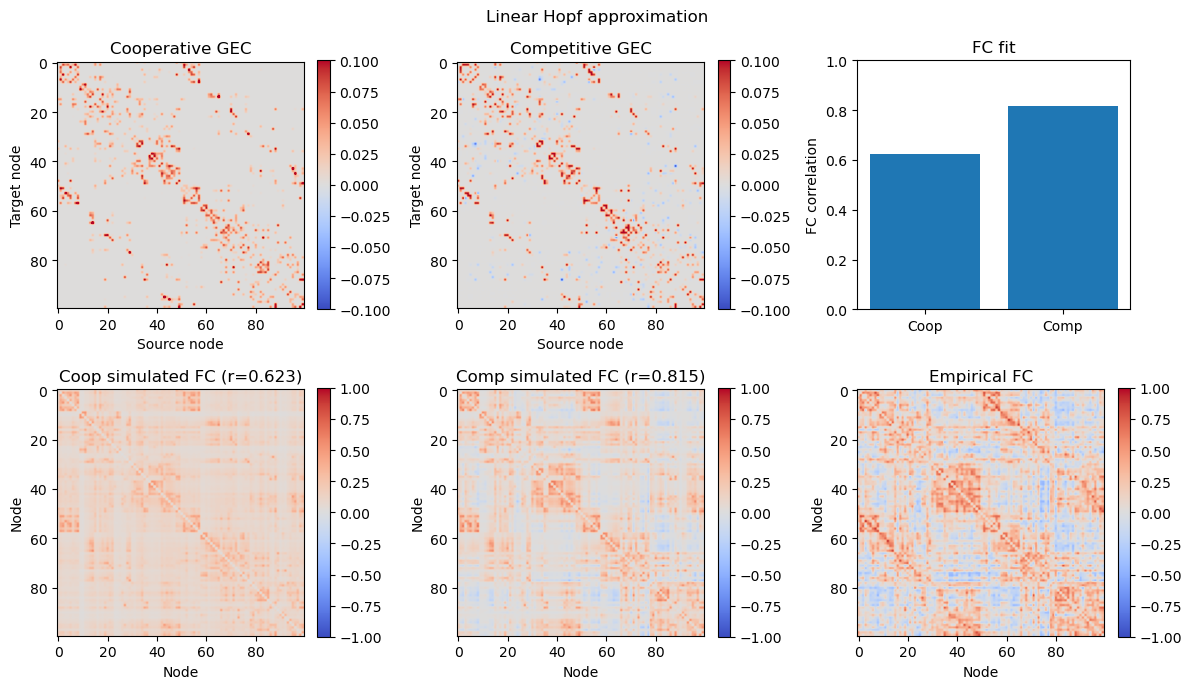

In [5]:
# Cell 5: linear Hopf approximation
# This block uses GenericHopf.get_jacobian() and is not Luppi2026-style nonlinear processing.

linear_model = GenericHopf()
linear_model.set_attributes({"a": A_PARAM, "frequency_hz": frequencies,})

linear_common = dict(
    sc=SC,
    empirical_fc=EMP_FC,
    empirical_normalized_shifted_covariance=EMP_LAG,
    tr_seconds=TR_SECONDS,
    linear_model=linear_model,
    sigma=SIGMA,
    learning_rate_fc=LEARNING_RATE_FC,
    n_iter=N_ITER,
    relative_tolerance=RELATIVE_TOLERANCE,
    l1_alpha=ALPHA_L1,
)

linear_coop = fit_lagcov_gec(**linear_common, max_c=MAX_C_COOP)
linear_comp = fit_lagcov_gec(**linear_common, allow_negative=True, max_c=MAX_C_COMP)
summarize_result("Linear coop", linear_coop)
summarize_result("Linear comp", linear_comp)
plot_luppi_style_comparison("Linear Hopf approximation", linear_coop, linear_comp)

/Users/zixuan.zhouchildmind.org/Documents/GitHub/neuromaps-prime-modeling/nmp_modeling/adapters/neuronumba/models/generic_hopf.py:115: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', True, aligned=True))
  incoming = np.dot(state, weights_t)


Sim coop     | best_iter= 103 | best_loss=0.0840118 | FC r=0.4291 | lag r=0.4215 | positive=1268, negative=0 | stop=loss increased at checkpoint
Sim comp     | best_iter= 486 | best_loss=0.0417663 | FC r=0.7688 | lag r=0.7601 | positive=1402, negative=858 | stop=loss increased at checkpoint


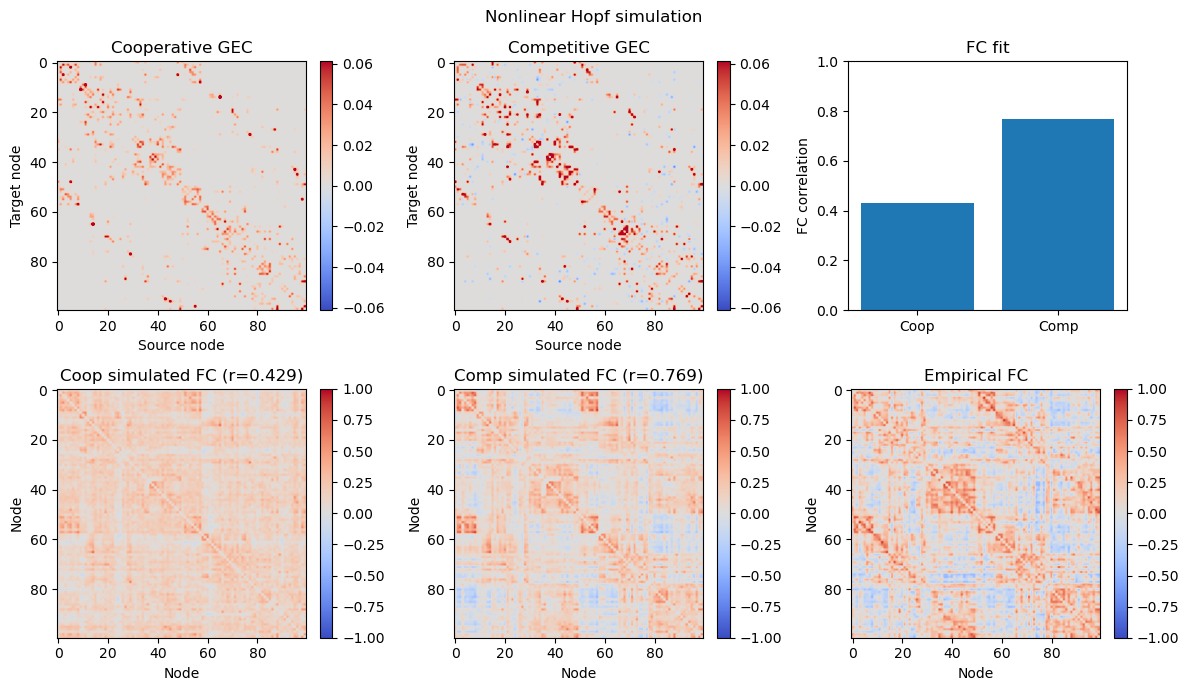

In [6]:
# Cell 6: nonlinear Hopf fitting with Neuronumba
# This block is closer to the Luppi 2026 workflow than the linear approximation.

TR_MS = TR_SECONDS * 1000.0
DT_MS = 0.1 * TR_MS / 2.0
SIM_DURATION_MS = (TS.shape[0] - 1) * TR_MS
SIM_WARMUP_MS = 3000.0 * 1000.0


def adapter_factory(weights):
    """Build a GenericHopf adapter for one candidate GEC matrix."""
    return NeuronumbaAdapter(
        weights=weights,
        model="GenericHopf",
        dt=DT_MS,
        sampling_period=TR_MS,
        sim_duration=SIM_DURATION_MS,
        sim_warmup=SIM_WARMUP_MS,
        sigma=SIGMA,
    )


simulation_common = dict(
    sc=SC,
    empirical_fc=EMP_FC,
    empirical_normalized_shifted_covariance=EMP_LAG,
    backend="simulation",
    adapter_factory=adapter_factory,
    theta={"a": A_PARAM, "frequency_hz": frequencies,},
    seeds=RUN_SEEDS,
    learning_rate_fc=LEARNING_RATE_FC,
    n_iter=N_ITER,
    relative_tolerance=RELATIVE_TOLERANCE,
    l1_alpha=ALPHA_L1,
)

sim_coop = fit_lagcov_gec(**simulation_common, max_c=MAX_C_COOP)
sim_comp = fit_lagcov_gec(**simulation_common, allow_negative=True, max_c=MAX_C_COMP)
summarize_result("Sim coop", sim_coop)
summarize_result("Sim comp", sim_comp)
plot_luppi_style_comparison("Nonlinear Hopf simulation", sim_coop, sim_comp)